# Iris Generativa com NatGenAI
Experimento didático para estudo de geração de dados sintéticos por Computação Evolutiva

## Pipeline

```text
Iris real
   │
   ├── setosa
   ├── versicolor
   └── virginica
          │
          ▼
 calibração por espécie
 novidade / plausibilidade / nichos
          │
          ▼
 mesmas populações iniciais por seed
          │
   ┌──────┼──────────┐
   │      │          │
   ▼      ▼          ▼
  SBX  OB-Scan   Híbrido 50/50
   │      │          │
   └──────┼──────────┘
          │
 RMP + herança de tarefa
          │
 seleção moderada por nichos
          │
 150 sintéticos por condição
          │
          ▼
 fidelidade / novidade / diversidade
 Wasserstein / KS / coerência / cópias
          │
          ▼
150 reais + 150 sintéticos
          │
 origem 1 / 0
          │
 Logistic Regression + Random Forest
          │
          ▼
 robustez / sensibilidade / cross-fit
```

## 1. Comparação controlada entre SBX, OB-Scan e uma condição híbrida

### Pergunta experimental central

> Como o uso de um operador centrado nos pais (**SBX**), de um operador disruptivo (**OB-Scan**) e da combinação dos dois afeta fidelidade, novidade, diversidade e distinguibilidade dos dados sintéticos da base Iris?

### Condições principais

1. **C1 — SBX:** 100% dos descendentes são produzidos por SBX;
2. **C2 — OB-Scan:** 100% dos descendentes são produzidos por OB-Scan-KDE;
3. **C3 — Híbrida:** 50% SBX + 50% OB-Scan.

A condição híbrida aproxima a configuração experimental descrita por Shi et al. (2025), na qual SBX e OB-Scan são aplicados com igual probabilidade.

## 2. Fundamentação e escopo

Este projeto distingue três níveis:

- **PyGAD:** biblioteca operacional usada para executar o **SBX** e, em experimento complementar, a **Polynomial Mutation**;
- **NatGenAI:** interpretação conceitual da Computação Evolutiva como mecanismo generativo orientado por busca;
- **extensões experimentais deste projeto:** OB-Scan-KDE, lógica multitarefa, RMP, seleção moderada e avaliação generativa.

A implementação **não é uma reprodução integral do MFEA/MTEC**. Ela preserva princípios centrais do artigo, mas adapta a arquitetura ao conjunto Iris e ao objetivo experimental do projeto.

### Fontes centrais

- Shi, Y. et al. *Evolutionary Computation as Natural Generative AI*. arXiv:2510.08590v1.
- Documentação oficial do PyGAD 3.7.0.
- Fisher, R. A. (1936), conjunto Iris.

# Parte I — Ambiente, dados e calibração

## 3. Ambiente e dependências

As versões utilizadas estão registradas em `requirements.txt` e `pyproject.toml`.

In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pygad
import sklearn
from sklearn.decomposition import PCA

from iris_generativa.config import (
    CV_SEED,
    GENERATIONS,
    MAIN_CONDITIONS,
    POP_SIZE,
    RMP,
    RUN_CROSSFIT,
    RUN_POLYNOMIAL_LAB,
    RUN_ROBUSTNESS,
    RUN_SENSITIVITY,
    SBX_ETA,
    SEED,
)
from iris_generativa.data import build_calibration_table, load_iris_data, prepare_context
from iris_generativa.evaluation import (
    build_discriminator_tables,
    build_distribution_table,
    summarize_generation,
)
from iris_generativa.experiments import (
    crossfit_generator_experiment,
    polynomial_mutation_experiment,
    robustness_experiment,
    run_main_experiment,
    sensitivity_experiment,
)

print(f"Python: {sys.version.split()[0]}")
print(f"NumPy: {np.__version__}")
print(f"pandas: {pd.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"PyGAD: {pygad.__version__}")

Python: 3.14.7
NumPy: 2.5.3
pandas: 3.0.6
scikit-learn: 1.9.1
PyGAD: 3.7.0


## 4. Configuração experimental

A comparação principal mantém os mesmos hiperparâmetros entre as condições. Assim, a principal variável manipulada é **o operador de recombinação**.

- `SBX_ETA = 50` reproduz a configuração usada no experimento MTEC + OB-Scan do artigo;
- `RMP = 0.20` mantém uma probabilidade moderada de cruzamento intertarefas;
- o experimento principal **não aplica mutação após o crossover**, evitando misturar duas fontes de variação;
- os laboratórios complementares permanecem controlados por flags em `config.py`.

In [2]:
config_df = pd.DataFrame(
    {
        "valor": {
            "SEED": SEED,
            "CV_SEED": CV_SEED,
            "POP_SIZE": POP_SIZE,
            "GENERATIONS": GENERATIONS,
            "RMP": RMP,
            "SBX_ETA": SBX_ETA,
        }
    }
)
display(config_df)

,valor
SEED,42.0
CV_SEED,2026.0
POP_SIZE,50.0
GENERATIONS,40.0
RMP,0.2
SBX_ETA,50.0


## 5. Base Iris

Cada registro é representado por quatro genes contínuos:

$$
\mathbf{x} = [s_l, s_w, p_l, p_w]
$$

correspondentes a:

- $s_l$: comprimento da sépala;
- $s_w$: largura da sépala;
- $p_l$: comprimento da pétala;
- $p_w$: largura da pétala.

In [3]:
data = load_iris_data()

X_real = data["x_real"]
y_species = data["y_species"]
feature_names = data["feature_names"]
species_names = data["species_names"]
real_df = data["real_df"]

print(f"Formato da base: {X_real.shape}")
display(real_df.head())

Formato da base: (150, 4)


,sepal length,sepal width,petal length,petal width,species_id,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [4]:
class_counts = real_df["species"].value_counts().reindex(species_names)
summary_real = real_df.groupby(
    "species",
    observed=True,
)[feature_names].agg(["mean", "std", "min", "max"])

display(class_counts.to_frame("n"))
display(summary_real.round(3))

,n
species,
setosa,50
versicolor,50
virginica,50


sepal length                  sepal width                   \
                   mean    std  min  max        mean    std  min  max   
species                                                                 
setosa            5.006  0.352  4.3  5.8       3.428  0.379  2.3  4.4   
versicolor        5.936  0.516  4.9  7.0       2.770  0.314  2.0  3.4   
virginica         6.588  0.636  4.9  7.9       2.974  0.322  2.2  3.8   

           petal length                  petal width                   
                   mean    std  min  max        mean    std  min  max  
species                                                                
setosa            1.462  0.174  1.0  1.9       0.246  0.105  0.1  0.6  
versicolor        4.260  0.470  3.0  5.1       1.326  0.198  1.0  1.8  
virginica         5.552  0.552  4.5  6.9       2.026  0.275  1.4  2.5

## 6. Contexto evolutivo reutilizável

Toda informação aprendida da base real é encapsulada em um **contexto**. Isso permite usar o mesmo motor tanto no experimento principal quanto no protocolo cross-fitted, no qual o gerador é calibrado apenas com os dados de treinamento de cada fold.

In [5]:
context = prepare_context(X_real, y_species, SEED)
calibration_df = build_calibration_table(context, species_names)

display(calibration_df.round(4))

,novelty_target,novelty_sigma,plausibility_scale
species,,,
setosa,0.1954,0.1101,0.3274
versicolor,0.2876,0.0985,0.4023
virginica,0.3442,0.1339,0.4781


## 7. Fitness generativo calibrado pelos dados

A função de fitness aprende valores separadamente em cada espécie:

$$
F(x)=0{,}50P(x)+0{,}25N(x)+0{,}25C(x)
$$

- **Plausibilidade:** recompensa indivíduos em regiões com densidade local comparável à espécie real;
- **Novidade:** recompensa distância do vizinho real próxima do padrão natural observado na própria espécie;
- **Coerência:** mede se a vizinhança do indivíduo é mais compatível com sua tarefa do que com as demais.

A implementação está em `iris_generativa/fitness.py`.

# Parte II — Operadores e motor evolutivo

## 8. Operadores

A implementação dos mecanismos de variação está em `iris_generativa/operators.py`.

- **SBX:** utiliza diretamente o operador nativo do PyGAD 3.7.0;
- **OB-Scan-KDE:** escolhe, gene a gene, o valor parental com maior densidade estimada na população atual;
- **Polynomial Mutation:** é utilizada somente no experimento complementar.

## 9. Motor evolutivo

`iris_generativa/evolution.py` concentra:

- inicialização das populações;
- seleção por torneio;
- escolha das tarefas parentais e RMP;
- seleção moderada por nichos;
- execução das gerações.

As três condições usam a mesma base, função de fitness, tamanho populacional, número de gerações, RMP, seleção moderada e seed. A diferença central é `p_sbx`.

## 10. Execução pareada das condições principais

Todas as condições começam com a **mesma seed**. Isso reduz ruído experimental porque diferenças observadas não são consequência de populações iniciais arbitrariamente distintas.

In [6]:
main_runs = run_main_experiment(context)

for condition_name, result in main_runs.items():
    print(
        f"{condition_name}: "
        f"{result['synthetic_x'].shape[0]} sintéticos gerados."
    )

SBX: 150 sintéticos gerados.
OB-Scan: 150 sintéticos gerados.
Híbrido 50/50: 150 sintéticos gerados.


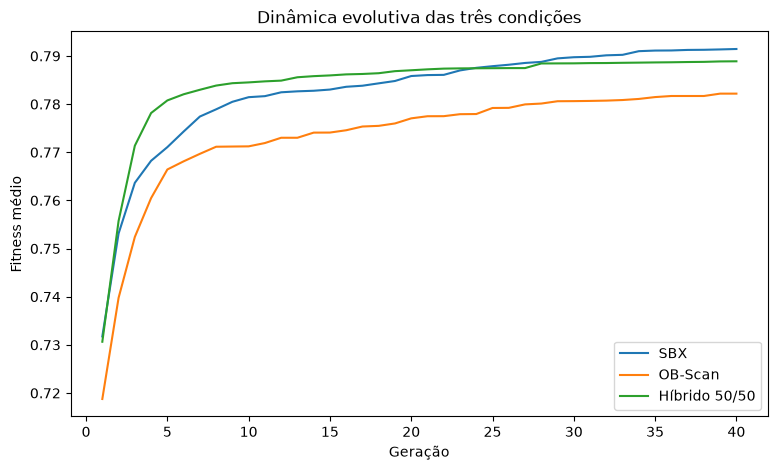

In [7]:
plt.figure(figsize=(9, 5))

for condition_name, result in main_runs.items():
    plt.plot(
        result["history"]["generation"],
        result["history"]["fitness_mean"],
        label=condition_name,
    )

plt.xlabel("Geração")
plt.ylabel("Fitness médio")
plt.title("Dinâmica evolutiva das três condições")
plt.legend()
plt.show()

# Parte III — Avaliação generativa comparativa

## 11. Métricas auxiliares

A avaliação separa quatro questões:

1. **cópia:** o gerador reproduziu registros reais exatamente?
2. **coerência:** a espécie atribuída ao sintético continua reconhecível?
3. **diversidade e novidade:** a população colapsou ou explora regiões novas?
4. **fidelidade distribucional:** reais e sintéticos possuem distribuições semelhantes?

As métricas estão em `iris_generativa/evaluation.py`.

## 12. Resumo por condição

A diversidade é calculada no espaço padronizado. A razão `diversity_ratio` próxima de 1 indica dispersão semelhante à base real; valores muito abaixo de 1 sugerem **convergência excessiva**.

In [8]:
summary_df, real_diversity = summarize_generation(
    main_runs,
    context,
    X_real,
    y_species,
)

display(summary_df.round(4))

,duplicates,species_coherence,novelty_mean,diversity,diversity_ratio
condition,,,,,
SBX,0,0.9933,0.2211,2.3312,0.9288
OB-Scan,0,0.9933,0.2228,2.2234,0.8858
Híbrido 50/50,0,0.9933,0.2263,2.2568,0.8991


## 13. Fidelidade univariada por espécie e atributo

Para cada condição, espécie e atributo calculamos:

- **Wasserstein-1:** deslocamento médio entre os quantis reais e sintéticos;
- **KS:** maior diferença entre as CDFs empíricas.

Valores menores indicam maior proximidade distribucional.

In [9]:
distribution_df = build_distribution_table(
    main_runs,
    X_real,
    y_species,
    feature_names,
    species_names,
    context["tasks"],
)

display(
    distribution_df.groupby("condition")[
        ["wasserstein", "ks"]
    ].mean().round(4)
)

,wasserstein,ks
condition,,
Híbrido 50/50,0.1279,0.3317
OB-Scan,0.1301,0.3783
SBX,0.1388,0.3867


## 14. PCA comum

O PCA é ajustado **somente na base real** e depois aplicado a todos os sintéticos. Assim, as três condições são comparadas no mesmo sistema de coordenadas e nenhuma delas altera a projeção usada como referência.

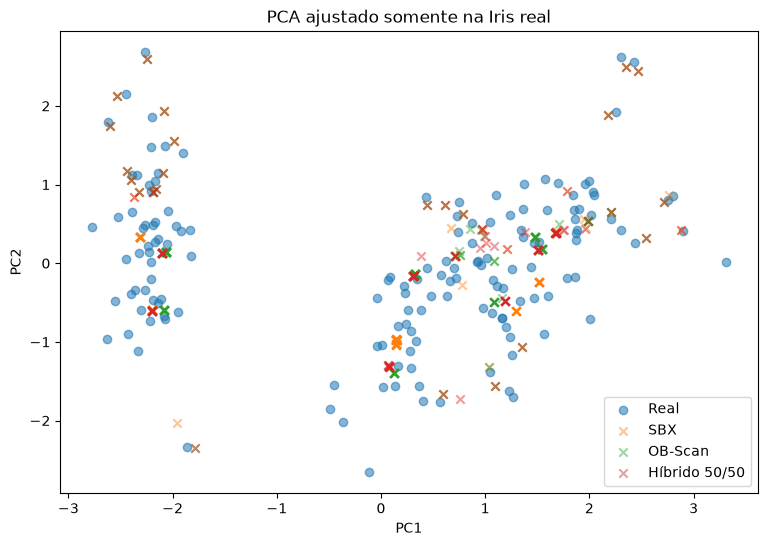

In [10]:
pca = PCA(n_components=2, random_state=SEED)
real_pca = pca.fit_transform(context["Z_real"])

plt.figure(figsize=(9, 6))
plt.scatter(
    real_pca[:, 0],
    real_pca[:, 1],
    alpha=0.55,
    marker="o",
    label="Real",
)

for condition_name, result in main_runs.items():
    synthetic_pca = pca.transform(result["synthetic_z"])
    plt.scatter(
        synthetic_pca[:, 0],
        synthetic_pca[:, 1],
        alpha=0.45,
        marker="x",
        label=condition_name,
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA ajustado somente na Iris real")
plt.legend()
plt.show()

## 15. Teste discriminativo Real × Sintético

Para cada condição construímos:

$$
150\ \text{reais} + 150\ \text{sintéticos} = 300\ \text{registros}
$$

com alvo:

- `1 = real`;
- `0 = sintético`.

A estratificação da validação cruzada considera simultaneamente **origem e espécie**, formando seis estratos. Isso preserva em cada *fold* tanto o equilíbrio Real × Sintético quanto a composição das três espécies.

In [11]:
discriminator_tables, comparison_df = build_discriminator_tables(
    main_runs,
    X_real,
    y_species,
    cv_seed=CV_SEED,
)

display(comparison_df.round(4))

,logistic_accuracy,rf_accuracy,rf_roc_auc
condition,,,
SBX,0.5307,0.8787,0.9400
OB-Scan,0.4700,0.9120,0.9540
Híbrido 50/50,0.5180,0.9060,0.9493


In [12]:
for condition_name, table in discriminator_tables.items():
    print(f"\n{condition_name}")
    display(table.round(4))


SBX


,accuracy_mean,precision_mean,recall_mean,f1_mean,roc_auc_mean,accuracy_std,precision_std,recall_std,f1_std,roc_auc_std
model,,,,,,,,,,
Regressão Logística,0.5307,0.5372,0.4867,0.5072,0.5229,0.0745,0.0865,0.0966,0.0803,0.0676
Random Forest,0.8787,0.8473,0.9293,0.8847,0.9400,0.0293,0.0463,0.0484,0.0267,0.0286



OB-Scan


,accuracy_mean,precision_mean,recall_mean,f1_mean,roc_auc_mean,accuracy_std,precision_std,recall_std,f1_std,roc_auc_std
model,,,,,,,,,,
Regressão Logística,0.470,0.4683,0.5213,0.4908,0.5215,0.0724,0.0682,0.1292,0.0911,0.0718
Random Forest,0.912,0.8716,0.9693,0.9172,0.9540,0.0311,0.0426,0.0297,0.0283,0.0233



Híbrido 50/50


,accuracy_mean,precision_mean,recall_mean,f1_mean,roc_auc_mean,accuracy_std,precision_std,recall_std,f1_std,roc_auc_std
model,,,,,,,,,,
Regressão Logística,0.518,0.5278,0.4893,0.5017,0.5315,0.0694,0.0802,0.0927,0.0678,0.0633
Random Forest,0.906,0.8579,0.9773,0.9128,0.9493,0.0346,0.0465,0.0336,0.0307,0.0253


## 16. Leitura dos resultados

A interpretação deve combinar as métricas:

- **Random Forest próxima de 0,50:** origem difícil de detectar mesmo por fronteiras não lineares;
- **Regressão Logística próxima de 0,50, mas Random Forest alta:** ausência de separação linear, porém existência de assinatura sintética não linear;
- **diversidade relativa muito abaixo de 1:** possível colapso populacional;
- **Wasserstein/KS elevados:** discrepâncias marginais detectáveis;
- **coerência baixa:** produção pouco compatível com a espécie atribuída;
- **duplicatas altas:** indistinguibilidade pode resultar de cópia, não de geração.

Nenhuma métrica isolada é suficiente para declarar um gerador “bom”.

# Parte IV — Experimentos controlados

Os experimentos abaixo permanecem opcionais e são coordenados por `iris_generativa/experiments.py`. As flags correspondentes ficam centralizadas em `config.py`.

## 17. Robustez em 20 sementes pareadas

As mesmas vinte seeds são usadas em todas as condições. O `CV_SEED` permanece fixo. Assim, a comparação entre operadores não é confundida por mudanças simultâneas na geração e na avaliação.

In [13]:
if RUN_ROBUSTNESS:
    robustness_df = robustness_experiment(
        context,
        X_real,
        y_species,
        real_diversity,
    )
    display(
        robustness_df.groupby("condition")[
            [
                "rf_accuracy",
                "rf_roc_auc",
                "diversity_ratio",
                "duplicates",
            ]
        ].agg(["mean", "std", "min", "max"]).round(4)
    )
else:
    robustness_df = pd.DataFrame()
    print(
        "Robustez desativada. "
        "Defina RUN_ROBUSTNESS = True em config.py."
    )

rf_accuracy                         rf_roc_auc                  \
                     mean     std     min     max       mean     std     min   
condition                                                                      
Híbrido 50/50      0.8753  0.0128  0.8553  0.8980     0.9388  0.0073  0.9243   
OB-Scan            0.8813  0.0185  0.8440  0.9153     0.9419  0.0109  0.9233   
SBX                0.8610  0.0138  0.8327  0.8800     0.9373  0.0074  0.9208   

                      diversity_ratio                         duplicates       \
                  max            mean     std     min     max       mean  std   
condition                                                                       
Híbrido 50/50  0.9591          0.9324  0.0214  0.9020  0.9672        0.0  0.0   
OB-Scan        0.9649          0.9199  0.0185  0.8868  0.9633        0.0  0.0   
SBX            0.9501          0.9402  0.0166  0.9083  0.9706        0.0  0.0   

                       
              min max  
condition              
Híbrido 50/50   0   0  
OB-Scan         0   0  
SBX             0   0

## 18. Sensibilidade do SBX, RMP e seleção moderada

Este experimento altera **uma variável por vez**:

- `SBX eta ∈ {5, 30, 50}`;
- `RMP ∈ {0.00, 0.20}`;
- seleção moderada `True/False`.

A condição de referência é restaurada para os demais parâmetros.

In [14]:
if RUN_SENSITIVITY:
    sensitivity_df = sensitivity_experiment(
        context,
        X_real,
        y_species,
        real_diversity,
    )
    display(sensitivity_df.round(4))
else:
    sensitivity_df = pd.DataFrame()
    print(
        "Sensibilidade desativada. "
        "Defina RUN_SENSITIVITY = True em config.py."
    )

,experiment,value,rf_accuracy,rf_roc_auc,diversity_ratio
0,SBX eta,5.0,0.8447,0.9104,0.9391
1,SBX eta,30.0,0.8767,0.9351,0.9301
2,SBX eta,50.0,0.8787,0.9400,0.9288
3,RMP,0.0,0.8940,0.9451,0.9095
4,RMP,0.2,0.9060,0.9493,0.8991
5,Seleção moderada,False,1.0000,1.0000,0.6630
6,Seleção moderada,True,0.9060,0.9493,0.8991


## 19. Experimento complementar — SBX + Polynomial Mutation

Este bloco não faz parte da comparação principal porque adicionaria uma segunda fonte de variação. Ele investiga uma configuração **inteiramente baseada em operadores nativos do PyGAD 3.7.0**:

$$
SBX + Polynomial\ Mutation
$$

In [15]:
if RUN_POLYNOMIAL_LAB:
    poly_results, poly_history = polynomial_mutation_experiment(
        context,
        X_real,
        y_species,
    )
    display(poly_results.round(4))
else:
    print(
        "Laboratório SBX + Polynomial Mutation desativado. "
        "Defina RUN_POLYNOMIAL_LAB = True em config.py."
    )

,accuracy_mean,precision_mean,recall_mean,f1_mean,roc_auc_mean,accuracy_std,precision_std,recall_std,f1_std,roc_auc_std
model,,,,,,,,,,
Regressão Logística,0.4860,0.4885,0.4400,0.4588,0.4755,0.0610,0.0709,0.0854,0.0684,0.0516
Random Forest,0.8833,0.8406,0.9493,0.8906,0.9356,0.0323,0.0399,0.0453,0.0301,0.0296


## 20. Protocolo cross-fitted do gerador

Este protocolo testa uma questão mais rigorosa:

> O gerador consegue produzir sintéticos semelhantes a registros reais que **não participaram de sua calibração**?

Em cada fold:

1. 120 registros reais calibram o contexto evolutivo;
2. 30 registros reais ficam completamente fora da geração;
3. o gerador produz 30 sintéticos — 10 por espécie;
4. um discriminador tenta separar os 30 reais inéditos dos 30 sintéticos.

O processo é repetido nos cinco folds e resumido por condição.

In [16]:
if RUN_CROSSFIT:
    crossfit_df = crossfit_generator_experiment(
        X_real,
        y_species,
    )
    display(
        crossfit_df.groupby("condition")[
            ["accuracy", "roc_auc"]
        ].agg(["mean", "std", "min", "max"]).round(4)
    )
else:
    crossfit_df = pd.DataFrame()
    print(
        "Cross-fitting desativado. "
        "Defina RUN_CROSSFIT = True em config.py."
    )

accuracy                         roc_auc                        
                  mean     std     min     max    mean     std     min     max
condition                                                                     
Híbrido 50/50   0.7400  0.0673  0.6333  0.8167  0.8453  0.0600  0.7467  0.9100
OB-Scan         0.7567  0.0778  0.6667  0.8667  0.8103  0.0864  0.7167  0.9283
SBX             0.7300  0.0462  0.6833  0.7833  0.8540  0.0384  0.8100  0.8967

# Parte V — Síntese metodológica

## 21. Perguntas experimentais

- **SBX × OB-Scan:** o operador disruptivo altera novidade e fidelidade?
- **Híbrido × operadores puros:** combinar exploração incremental e disruptiva produz melhor equilíbrio?
- **RMP 0 × 0,20:** transferência intertarefas ajuda ou prejudica?
- **Seleção direta × moderada:** preservar nichos reduz colapso populacional?
- **$\eta = 5 \times 30 \times 50$:** o quanto a concentração do SBX em torno dos pais muda a assinatura sintética?
- **full-data × cross-fitted:** o comportamento se mantém quando avaliamos dados reais que o gerador nunca viu?

O objetivo não é procurar apenas a menor acurácia do discriminador. Um gerador de qualidade precisa equilibrar:

$$
\text{fidelidade}
+
\text{novidade}
+
\text{diversidade}
+
\text{coerência}
$$

## 22. Limitações

1. a Iris é pequena, balanceada e de baixa dimensionalidade;
2. a lógica multitarefa é inspirada em MFEA/MTEC, mas não constitui reprodução integral desses algoritmos;
3. o OB-Scan-KDE foi integrado ao motor multitarefa próprio do projeto, não ao ciclo interno completo de `pygad.GA`;
4. os pesos do fitness continuam sendo uma escolha experimental;
5. o teste discriminativo mede distinguibilidade, não “qualidade generativa” completa;